In [7]:
import time
import pandas as pd
from nba_api.stats.endpoints import playergamelogs


In [8]:
LUKA_ID = 1629029

In [ ]:
logs = playergamelogs.PlayerGameLogs(
    player_id_nullable=LUKA_ID,
    season_nullable = '2023-24'
)

In [14]:
df = logs.get_data_frames()[0]
print(df.shape)
df.head()

(96, 70)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT
0,2023-24,1629029,Luka Dončić,Luka,1610612742,DAL,Dallas Mavericks,0042300405,2024-06-17T00:00:00,DAL @ BOS,...,47,68,91,73,1,29,65,1,43:23,1
1,2023-24,1629029,Luka Dončić,Luka,1610612742,DAL,Dallas Mavericks,0042300404,2024-06-14T00:00:00,DAL vs. BOS,...,62,61,5,75,66,29,85,1,32:32,1
2,2023-24,1629029,Luka Dončić,Luka,1610612742,DAL,Dallas Mavericks,0042300403,2024-06-12T00:00:00,DAL vs. BOS,...,77,74,36,87,66,29,87,1,37:44,1
3,2023-24,1629029,Luka Dončić,Luka,1610612742,DAL,Dallas Mavericks,0042300402,2024-06-09T00:00:00,DAL @ BOS,...,77,47,65,23,1,1,18,1,42:17,1
4,2023-24,1629029,Luka Dončić,Luka,1610612742,DAL,Dallas Mavericks,0042300401,2024-06-06T00:00:00,DAL @ BOS,...,47,55,75,85,1,29,75,1,38:14,1


In [15]:
print(df.columns.tolist())

['SEASON_YEAR', 'PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'AVAILABLE_FLAG', 'MIN_SEC', 'TEAM_COUNT']


In [16]:
df.to_parquet('../data/raw/luka_2023_24.parquet', index=False)
print('saved')

saved


In [18]:
df = pd.read_parquet('../data/raw/luka_2023_24.parquet')
df[['GAME_DATE', 'MATCHUP', 'PTS', 'REB', 'AST', 'MIN']].head(15)

,GAME_DATE,MATCHUP,PTS,REB,AST,MIN
0,2024-06-17T00:00:00,DAL @ BOS,28,12,5,43.383333
1,2024-06-14T00:00:00,DAL vs. BOS,29,5,5,32.540000
2,2024-06-12T00:00:00,DAL vs. BOS,27,6,6,37.725000
3,2024-06-09T00:00:00,DAL @ BOS,32,11,11,42.285000
4,2024-06-06T00:00:00,DAL @ BOS,30,10,1,38.233333
5,2024-05-30T00:00:00,DAL @ MIN,36,10,5,36.583333
6,2024-05-28T00:00:00,DAL vs. MIN,28,15,10,40.740000
7,2024-05-26T00:00:00,DAL vs. MIN,33,7,5,41.200000
8,2024-05-24T00:00:00,DAL @ MIN,32,10,13,41.450000
9,2024-05-22T00:00:00,DAL @ MIN,33,6,8,40.738333


In [19]:
# Will only be keeping the following columns. There is a lot of noise


# KEEP = [
#     # identity
#     'PLAYER_ID', 'PLAYER_NAME', 'SEASON_YEAR',
#     'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL',

#     # performance — our targets and inputs
#     'MIN', 'PTS', 'REB', 'AST', 'TOV', 'STL', 'BLK',

#     # shooting breakdown — useful features later
#     'FGM', 'FGA', 'FG_PCT',
#     'FG3M', 'FG3A', 'FG3_PCT',
#     'FTM', 'FTA', 'FT_PCT',

#     # other useful context
#     'PLUS_MINUS', 'OREB', 'DREB',
# ]


In [ ]:
# Clean
KEEP = [
    'PLAYER_ID', 'PLAYER_NAME', 'SEASON_YEAR',
    'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL',
    'MIN', 'PTS', 'REB', 'AST', 'TOV', 'STL', 'BLK',
    'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
    'FTM', 'FTA', 'FT_PCT', 'PLUS_MINUS', 'OREB', 'DREB',
]

df = df[KEEP].copy()
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
df['HOME'] = (~df['MATCHUP'].str.contains('@')).astype(int)
df = df.sort_values('GAME_DATE').reset_index(drop=True)

print(df.shape)
df.head()

(96, 27)


,PLAYER_ID,PLAYER_NAME,SEASON_YEAR,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,REB,...,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,PLUS_MINUS,OREB,DREB,HOME
0,1629029,Luka Dončić,2023-24,0012300001,2023-10-05,DAL @ MIN,L,16.983333,25,5,...,3,8,0.375,6,7,0.857,-13,1,4,0
1,1629029,Luka Dončić,2023-24,0012300002,2023-10-07,DAL vs. MIN,L,18.866667,18,5,...,2,7,0.286,6,7,0.857,-1,1,4,1
2,1629029,Luka Dončić,2023-24,0012300013,2023-10-10,DAL @ RMD,L,4.983333,9,0,...,3,5,0.600,0,0,0.000,-6,0,0,0
3,1629029,Luka Dončić,2023-24,0022300073,2023-10-25,DAL @ SAS,W,34.241667,33,13,...,3,11,0.273,4,7,0.571,4,1,12,0
4,1629029,Luka Dončić,2023-24,0022300084,2023-10-27,DAL vs. BKN,W,36.030000,49,10,...,9,14,0.643,8,10,0.800,9,1,9,1


In [21]:
# Check for missing values
print(df.isnull().sum())

PLAYER_ID      0
PLAYER_NAME    0
SEASON_YEAR    0
GAME_ID        0
GAME_DATE      0
MATCHUP        0
WL             0
MIN            0
PTS            0
REB            0
AST            0
TOV            0
STL            0
BLK            0
FGM            0
FGA            0
FG_PCT         0
FG3M           0
FG3A           0
FG3_PCT        0
FTM            0
FTA            0
FT_PCT         0
PLUS_MINUS     0
OREB           0
DREB           0
HOME           0
dtype: int64


In [22]:
df.to_parquet('../data/processed/luka_cleaned_2023_24.parquet', index=False)
print('saved')

saved


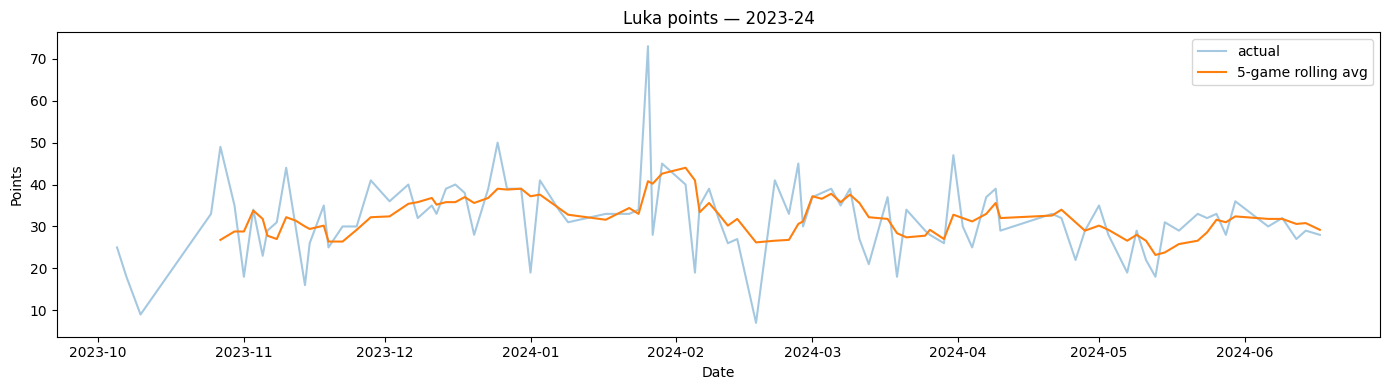

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df['GAME_DATE'], df['PTS'], alpha=0.4, label='actual')
plt.plot(df['GAME_DATE'], df['PTS'].rolling(5).mean(), label='5-game rolling avg')
plt.title('Luka points — 2023-24')
plt.xlabel('Date')
plt.ylabel('Points')
plt.legend()
plt.tight_layout()
plt.show()

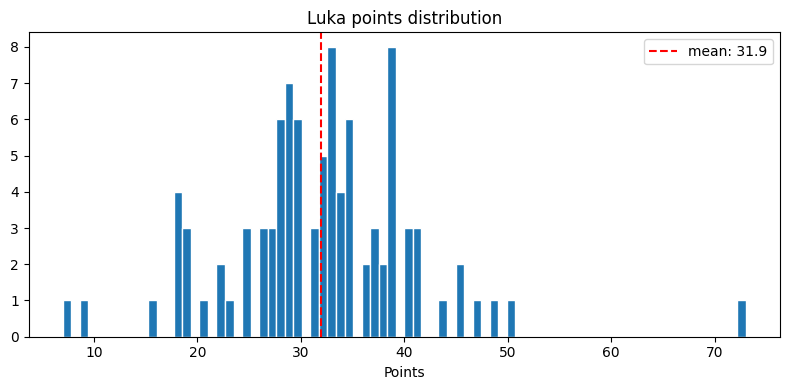

In [28]:
plt.figure(figsize=(8, 4))
plt.hist(df['PTS'], bins=80, edgecolor='white')
plt.axvline(df['PTS'].mean(), color='red', linestyle='--', label=f"mean: {df['PTS'].mean():.1f}")
plt.title('Luka points distribution')
plt.xlabel('Points')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(df.groupby('HOME')[['PTS','REB', 'AST']].mean().round(2))

        PTS   REB   AST
HOME                   
0     31.73  9.02  8.82
1     32.13  9.16  9.53


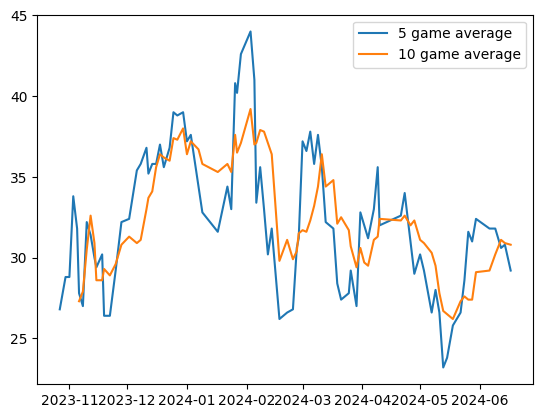

In [32]:
df['PTS_rolling_5'] = df['PTS'].rolling(window=5).mean()
df['PTS_rolling_10'] = df['PTS'].rolling(window=10).mean()
plt.plot(df['GAME_DATE'], df['PTS_rolling_5'], label='5 game average')
plt.plot(df['GAME_DATE'], df['PTS_rolling_10'], label='10 game average')
plt.legend()
plt.show()

In [35]:
df['PLAYOFF'] = df['GAME_ID'].astype(str).str.startswith('004').astype(int)

In [36]:
print(df.groupby('PLAYOFF')[['PTS','REB', 'AST']].mean().round(2))

           PTS   REB   AST
PLAYOFF                   
0        32.82  8.97  9.47
1        28.86  9.45  8.09


In [37]:
df.groupby('PLAYOFF')['PTS'].std()

PLAYOFF
0    9.755024
1    4.833371
Name: PTS, dtype: float64

In [38]:
df.groupby('HOME')['PTS'].std()

HOME
0    10.137215
1     7.629488
Name: PTS, dtype: float64

In [42]:
df.groupby(['PLAYOFF','HOME'])['PTS'].agg(['mean','std','max','min','count'])

mean        std  max  min  count
PLAYOFF HOME                                       
0       0     32.000000  11.374024   73    7     39
        1     33.742857   7.620957   49   18     35
1       0     30.833333   4.365845   36   19     12
        1     26.500000   4.453463   33   18     10